In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

In [15]:
X,y = make_blobs(n_samples=1000, n_features=2, centers=3)
#X stores the 2 input features for every sample pt.
#y is an array that store the output classes of each of the 1000samples
#centers=3 means 3 centroids i.e,3 clusters

In [8]:
X,y

(array([[ 8.77464714,  9.1280905 ],
        [-7.0436863 , -6.64176705],
        [ 9.09054586, 10.02981032],
        ...,
        [-7.83813634, -5.19449805],
        [-6.69598842, -6.44042435],
        [ 8.39692604, 11.14722943]]),
 array([2, 1, 2, 1, 1, 0, 2, 0, 0, 2, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 1,
        2, 2, 1, 1, 1, 0, 2, 1, 0, 2, 1, 2, 0, 0, 0, 1, 1, 1, 2, 0, 0, 1,
        1, 2, 2, 1, 2, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 0, 1, 1, 0,
        1, 2, 2, 0, 1, 0, 0, 1, 0, 0, 2, 2, 2, 1, 2, 1, 1, 2, 0, 0, 2, 2,
        1, 0, 2, 2, 2, 2, 0, 2, 0, 1, 0, 1, 2, 0, 0, 1, 1, 0, 1, 1, 2, 1,
        2, 0, 2, 0, 1, 0, 2, 2, 1, 2, 0, 1, 1, 0, 1, 1, 2, 0, 0, 2, 0, 2,
        2, 2, 1, 2, 0, 2, 2, 1, 2, 2, 1, 0, 0, 1, 2, 1, 0, 0, 2, 0, 0, 2,
        1, 0, 0, 2, 1, 2, 0, 1, 1, 0, 0, 2, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2,
        2, 1, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 1, 1, 2, 0, 0, 1, 2, 1, 1,
        2, 0, 1, 2, 1, 0, 0, 1, 0, 0, 1, 2, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
        2, 1, 2, 0, 1, 1, 2, 

In [8]:
len((y))

1000

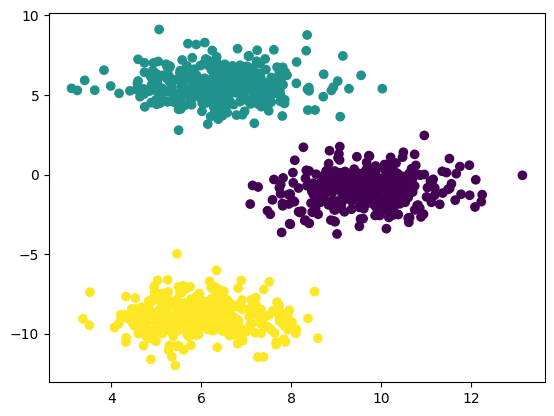

In [16]:
plt.scatter(X[:,0],X[:,1],c=y)

In [17]:
#Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
#train test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [33]:
#fitting the data into scaler after split to prevent data leakage
#only input is scaled not output

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
#KMeans cluster

from sklearn.cluster import KMeans

#Elbow method
wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)    #kmeans.inertia_ calculates the sum of squares of dist.

In [35]:
wcss

[1339.9999999999982,
 677.0425955201582,
 206.33574077119974,
 170.77460211926982,
 131.8893143399296,
 85.88266576963419,
 73.76457622756668,
 63.73399468623335,
 54.539648915456056,
 48.73283994285941]

Text(0, 0.5, 'WCSS')

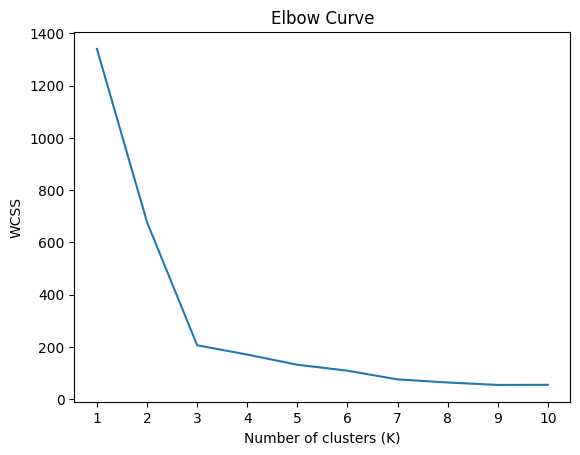

In [22]:
#Plotting Elbow curve

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.title('Elbow Curve')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')

So here the Elbow is at K = 3, thus we can make 3 clusters

In [23]:
kmeans = KMeans(n_clusters=3,init='k-means++')
kmeans.fit(X_train_scaled)
kmeans.predict(X_train_scaled)    #predicting o/p for train data

array([2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 1, 0, 1, 1, 0,
       2, 1, 2, 2, 2, 0, 1, 2, 2, 2, 2, 0, 1, 2, 1, 0, 0, 0, 2, 1, 0, 0,
       2, 0, 1, 2, 0, 2, 2, 1, 0, 1, 2, 1, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 2, 2, 0, 1, 1, 2, 1, 1, 0, 2, 0, 0, 0, 0, 1, 2, 1, 2, 2,
       0, 1, 2, 2, 1, 2, 0, 0, 2, 2, 1, 1, 0, 0, 2, 1, 1, 1, 0, 1, 0, 2,
       0, 1, 0, 1, 2, 1, 2, 0, 1, 2, 1, 1, 0, 1, 2, 1, 2, 2, 1, 0, 0, 1,
       1, 2, 1, 1, 0, 0, 0, 2, 2, 1, 2, 0, 2, 1, 0, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 1, 2, 0, 0, 0, 1, 2, 0, 0, 1, 0, 2, 0, 1, 0, 0, 1, 0, 1, 2,
       0, 2, 1, 2, 0, 0, 2, 0, 2, 2, 1, 0, 1, 0, 1, 0, 2, 0, 2, 2, 0, 0,
       2, 0, 2, 0, 1, 0, 2, 0, 0, 2, 1, 2, 0, 2, 1, 1, 1, 0, 1, 2, 2, 1,
       0, 0, 1, 0, 2, 0, 1, 1, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 1, 2, 2,
       0, 0, 2, 1, 0, 2, 1, 2, 1, 2, 2, 0, 1, 2, 1, 1, 1, 2, 0, 2, 2, 2,
       2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 1, 2, 1, 1, 0, 0, 2, 1, 2, 2, 2,
       0, 2, 1, 2, 0, 1, 0, 2, 1, 1, 0, 1, 0, 0, 0,

In [24]:
y_pred = kmeans.predict(X_test_scaled)
y_pred

array([0, 0, 2, 0, 0, 0, 2, 0, 1, 2, 2, 2, 0, 2, 1, 0, 2, 0, 2, 0, 1, 2,
       2, 0, 1, 1, 1, 2, 0, 0, 0, 1, 2, 2, 1, 0, 1, 1, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 2, 1, 1, 1, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 0, 1,
       1, 0, 2, 1, 0, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 2, 2, 0, 1, 2, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 2, 0, 0, 1, 0, 1, 0, 2, 1, 1, 1, 0,
       0, 2, 2, 0, 1, 1, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 1, 1, 1, 0, 0, 2,
       1, 0, 2, 0, 2, 1, 1, 1, 1, 2, 0, 0, 2, 1, 2, 0, 2, 1, 0, 1, 2, 1,
       2, 0, 0, 0, 1, 2, 0, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1,
       2, 0, 2, 2, 1, 1, 1, 2, 2, 0, 2, 2, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1,
       0, 2, 0, 1, 1, 0, 2, 0, 0, 2, 1, 1, 1, 2, 2, 2, 0, 2, 1, 2, 2, 1,
       0, 1, 2, 2, 1, 0, 2, 0, 1, 2, 2, 2, 1, 2, 2, 0, 1, 1, 2, 0, 2, 0,
       1, 1, 2, 1, 1, 1, 1, 0, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 1, 2, 1, 1,
       0, 1, 0, 1, 2, 0, 0, 0, 0, 2, 0, 1, 1, 2, 1, 1, 0, 2, 1, 1, 1, 2,
       1, 0, 0, 1, 2, 0, 2, 2, 2, 0, 2, 1, 1, 1, 2,

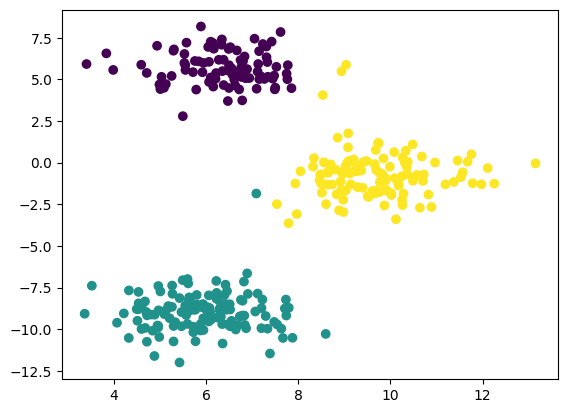

In [25]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [26]:
#Validating K value
#1.kneelocator

!pip install -q kneed


In [28]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')  #curve provides the kneelocator the shape of the graph and as the slope is decreasing it is shown by direction
print(kl.elbow)      #displays the actual elbow

3


Thus it i validated that we took correct value of k, earlier.

In [42]:
#2.Silhoutte scoring

from sklearn.metrics import silhouette_score
silhouette_coefficients = []

for k in range(2,11):
  kmeans = KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train_scaled)
  score = silhouette_score(X_train_scaled,kmeans.labels_)
  silhouette_coefficients.append(score)

silhouette_coefficients

[np.float64(0.5263697058178988),
 np.float64(0.6708795462866954),
 np.float64(0.5941563169719243),
 np.float64(0.5257646416363657),
 np.float64(0.4810645420496383),
 np.float64(0.4532336574483904),
 np.float64(0.4337672515085272),
 np.float64(0.4203943772828601),
 np.float64(0.4088747892075684)]

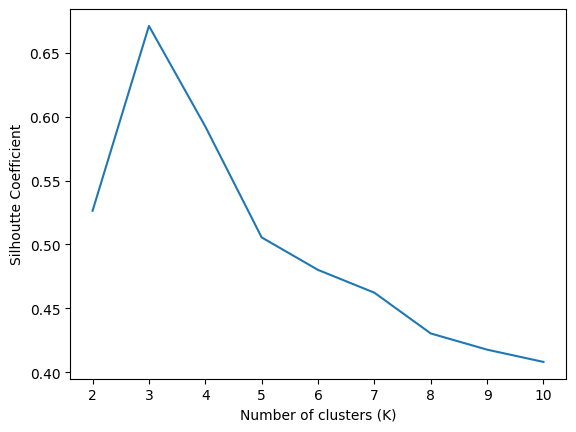

In [39]:
#Plotting silhoutte scores
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhoutte Coefficient')
plt.show()

So, from this technique, the k value for which silhoute coefficient is maximum should be chosen. So k=3 chosen and validated.